# Modelo 

### Ajustar los parámetros (dropout, ...)

In [11]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking, Bidirectional, Dropout
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import EarlyStopping

Primero crearemos la LSTM Simple, posteriormente aplicaremos validacion cruzada, y por último aplicaremos validacion cruzada y ajustaremos algunos parametros    
Después haremos lo mismo eliminando los videos ruidosos 

En la segunda fase haremos crearemos una LSTM Simple con angulos articulares, después aplicaremos validacion cruzada y por último validacion cruzada ajustando parametros    
Al igual que antes, volveremos a realizar los cálculos eliminando los videos ruidosos.

Finalmente compararemos todos los modelos en una gráfica

## Coordenadas de puntos clave como datos de entrada del modelo

### Carga de datos

In [ ]:
X_correct = np.load('../Data/Processed/Mixed_original_mirrored/mixed_correct_push_ups_landmarks.npy')
X_incorrect = np.load('../Data/Processed/Mixed_original_mirrored/mixed_wrong_push_ups_landmarks.npy')

X = np.vstack((X_correct, X_incorrect))
y = np.array([1]*X_correct.shape[0] + [0]*X_incorrect.shape[0])  

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
X_train.shape[1]

160

In [15]:
timesteps = X_train.shape[1]  # 160 frames (numero de frames por secuencia)
features = X_train.shape[2]   # 66 valores por frame

### LSTM Simple

In [16]:
model = Sequential()
model.add(Masking(mask_value=0., input_shape=(timesteps, features)))  # ignorar padding
model.add(LSTM(64, return_sequences=False))  # 64 unidades LSTM, solo devolvemos la última salida
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))    # salida binaria

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=35,
    batch_size=16
)

Epoch 1/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.4766 - loss: 0.6907 - val_accuracy: 0.7188 - val_loss: 0.6676
Epoch 2/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7188 - loss: 0.6592 - val_accuracy: 0.7500 - val_loss: 0.6078
Epoch 3/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7969 - loss: 0.5791 - val_accuracy: 0.6250 - val_loss: 0.6649
Epoch 4/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6172 - loss: 0.6611 - val_accuracy: 0.8438 - val_loss: 0.5640
Epoch 5/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7266 - loss: 0.5897 - val_accuracy: 0.6875 - val_loss: 0.6288
Epoch 6/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5234 - loss: 0.7178 - val_accuracy: 0.6562 - val_loss: 0.6289
Epoch 7/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7500 - loss: 0.5752 - val_accuracy: 0.8750 - val_loss: 0.5807
Epoch 8/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7812 - loss: 0.6411 - val_accuracy: 0.7188 - val_loss: 0.5728


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7000 - loss: 0.5738 
Test Accuracy: 0.70


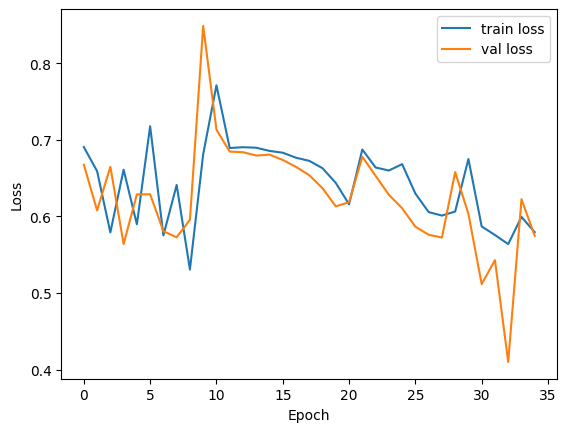

In [17]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")


plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Obtenemos un buen accuracy pero con picos de inestabilidad

### Validación cruzada

#### Creación de funciones de validacion cruzada y visualización 

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

# ==============================================================================
# FUNCIÓN 1: Ejecutar el Experimento de K-Fold (CON FLEXIBILIDAD)
# ==============================================================================
def run_kfold_experiment(model_fn, X_train, y_train, epochs, batch_size, n_splits=5, patience=None):
    """
    Ejecuta la validación cruzada K-Fold y devuelve métricas e historias.
    
    Args:
        model_fn: Función que devuelve un modelo Keras compilado.
        X_train, y_train: Datos de entrenamiento completos.
        epochs, batch_size: Parámetros de entrenamiento.
        n_splits: Número de pliegues (K).
        patience: Número de épocas de paciencia para EarlyStopping. 
                  Si es None (valor por defecto), EarlyStopping se omite.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    fold_accuracies = []
    fold_losses = []
    fold_histories = []
    
    # 1. PREPARACIÓN DEL CALLBACKS LIST
    callbacks_list = []
    if patience is not None and patience > 0:
        early_stopping = EarlyStopping(
            monitor='val_loss', 
            patience=patience, 
            restore_best_weights=True,
            verbose=0
        )
        callbacks_list.append(early_stopping) # Añadir a la lista solo si se solicita
        print(f"| INFO: EarlyStopping activado con paciencia={patience} |")

    print(f"Iniciando la validación cruzada de {n_splits} pliegues...")
    print("===" * 15)
    
    # Obtener dimensiones
    _, timesteps, features = X_train.shape

    fold_n = 1
    for train_index, val_index in kf.split(X_train):
        print(f"| Entrenando Pliegue {fold_n}/{n_splits}...")

        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        # Crear y compilar el modelo
        model = model_fn(timesteps, features) 

        # Entrenar el modelo
        history = model.fit(
            X_train_fold, y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks_list, # Usamos la lista de callbacks, que puede estar vacía
            verbose=0
        )
        
        # Guardar resultados y evaluar
        fold_histories.append(history.history)
        loss, acc = model.evaluate(X_val_fold, y_val_fold, verbose=0)
        fold_accuracies.append(acc)
        fold_losses.append(loss)
        print(f"| Precisión de Validación (Pliegue {fold_n}): {acc:.4f} | Pérdida: {loss:.4f}")
        
        fold_n += 1

    print("===" * 15)
    
    # Calcular métricas finales
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)

    print(f"✅ Validación Cruzada Completada con {n_splits} Pliegues.")
    print(f"| Precisión Media de Validación: **{mean_acc:.4f}**")
    print(f"| Desviación Estándar de la Precisión: **{std_acc:.4f}**")
    print("===" * 15)
    
    return mean_acc, std_acc, fold_histories

In [19]:
# ==============================================================================
# FUNCIÓN 2: Graficar las Historias de K-Fold
# ==============================================================================
def plot_kfold_history(fold_histories, title='Curvas de Pérdida Promedio de Validación Cruzada (K=5)'):
    """Genera un gráfico de la pérdida promedio y la desviación estándar de las historias de K-Fold."""
    
    # Determinar el número de épocas y pliegues
    N_SPLITS = len(fold_histories)
    if not fold_histories:
        print("Error: La lista fold_histories está vacía.")
        return
        
    num_epochs = min(len(hist['loss']) for hist in fold_histories)

    all_train_loss = np.zeros((N_SPLITS, num_epochs))
    all_val_loss = np.zeros((N_SPLITS, num_epochs))

    # Llenar los arrays con los datos (usando slicing para manejar Early Stopping)
    for i, hist in enumerate(fold_histories):
        all_train_loss[i] = hist['loss'][:num_epochs]
        all_val_loss[i] = hist['val_loss'][:num_epochs]

    # Calcular la media y la desviación estándar
    mean_train_loss = np.mean(all_train_loss, axis=0)
    std_train_loss = np.std(all_train_loss, axis=0)
    mean_val_loss = np.mean(all_val_loss, axis=0)
    std_val_loss = np.std(all_val_loss, axis=0)

    # Generación del Gráfico
    plt.figure(figsize=(10, 6))

    # Pérdida de entrenamiento promedio
    plt.plot(mean_train_loss, label='Pérdida de Entrenamiento Promedio', color='blue')
    plt.fill_between(range(num_epochs), 
                     mean_train_loss - std_train_loss, 
                     mean_train_loss + std_train_loss, 
                     color='blue', alpha=0.1)

    # Pérdida de validación promedio
    plt.plot(mean_val_loss, label='Pérdida de Validación Promedio (K-Fold)', color='red')
    plt.fill_between(range(num_epochs), 
                     mean_val_loss - std_val_loss, 
                     mean_val_loss + std_val_loss, 
                     color='red', alpha=0.1)

    plt.title(title)
    plt.xlabel('Época')
    plt.ylabel('Pérdida (Binary Crossentropy)')
    plt.legend()
    plt.grid(True)
    plt.show()

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.7500 | Pérdida: 0.5943
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.8125 | Pérdida: 0.6236
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.7812 | Pérdida: 0.4248
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.7500 | Pérdida: 0.5131
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.6250 | Pérdida: 0.6848
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.7438**
| Desviación Estándar de la Precisión: **0.0637**


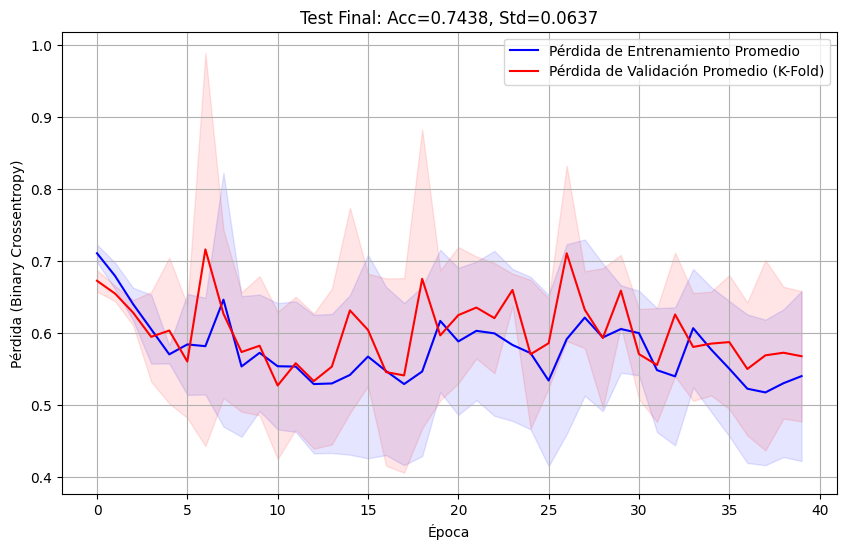

In [21]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False)) 
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

# --- EJECUCIÓN DEL EXPERIMENTO ---
# Asume que X_train y y_train están cargados.

mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

### Validadicón cruzada ajustando parámetros

Dropout de 20%, 32 unidades 

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.7812 | Pérdida: 0.5146
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.8438 | Pérdida: 0.4832
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.8125 | Pérdida: 0.4606
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.6875 | Pérdida: 0.6101
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.7500 | Pérdida: 0.5819
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.7750**
| Desviación Estándar de la Precisión: **0.0538**


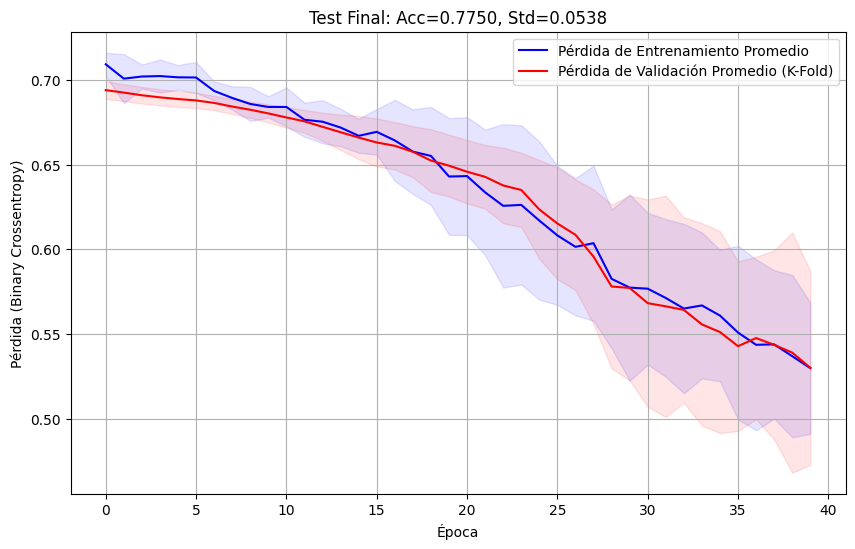

In [ ]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(32, return_sequences=False)) # <-- ¡Dropout recurrente añadido!
    
    # 3. Dropout (Regularización después de la LSTM)
    model.add(Dropout(0.2)) 
    model.add(Dense(32, activation='relu'))
    # 5. Dropout Opcional (Regularización después de la Densa)
    model.add(Dropout(0.2)) 
    model.add(Dense(1, activation='sigmoid'))

    custom_adam = Adam(learning_rate=0.0001) # <-- Nueva Tasa de Aprendizaje

    model.compile(
        loss='binary_crossentropy',
        optimizer=custom_adam,
        metrics=['accuracy']
    )
    return model

mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

Los resultados de accuracy y la desvicion son practicamente iguales que son dropout y con 128 unidades en vez de 32

### LSTM Simple sin videos ruidosos

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.losses import binary_crossentropy

# --- A. Entrenar un Modelo Único para el Análisis ---

# Re-entrenamos el modelo con todos los datos de entrenamiento (X_train)
# para obtener un buen conjunto de pesos para el análisis.
ANALYSIS_EPOCHS = 40  # Puedes usar 40 o el número de épocas que te dio el mejor resultado

print("Entrenando modelo para análisis de pérdida...")
analysis_model = create_lstm_model(timesteps, features)

# Entrenamos sin validación aquí, ya que el objetivo es el análisis de pérdida en X_train.
analysis_model.fit(
    X_train, y_train,
    epochs=ANALYSIS_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

# --- B. Calcular la Pérdida por Muestra en X_train ---

print("Calculando la pérdida individual por muestra...")
# 1. Obtener las predicciones del modelo en el conjunto de entrenamiento (X_train)
y_pred_proba = analysis_model.predict(X_train)

# Convertir y_train de la forma (80,) a la forma (80, 1) para que coincida con la predicción (80, 1).
y_train_reshaped = np.expand_dims(y_train, axis=-1)

# 2. Convertir a tensores para el cálculo de la pérdida
y_train_tf = tf.convert_to_tensor(y_train_reshaped, dtype=tf.float32) # <-- Usamos el array reformateado
y_pred_tf = tf.convert_to_tensor(y_pred_proba, dtype=tf.float32)

# 3. Calcular la Binary Crossentropy (pérdida) para cada muestra
# Esto ya no generará error ya que ambas variables son ahora 2D.
losses_per_sample = binary_crossentropy(y_train_tf, y_pred_tf)
losses_np = losses_per_sample.numpy()

# --- C. Identificar los Índices Ruidosos ---

# 1. Definir el porcentaje de ruido a buscar (ej: el 5% de las muestras con mayor pérdida)
PERCENTAJE_RUIDO = 0.05
num_total_samples = len(X_train)
num_noisy_samples = int(num_total_samples * PERCENTAJE_RUIDO)

# 2. Obtener los índices de las muestras ordenadas por pérdida (mayor a menor)
# np.argsort devuelve los índices que ordenarían el array
noisy_indices = np.argsort(losses_np)[::-1] # [::-1] invierte el orden para obtener los mayores primero

# 3. Seleccionar los top N índices más ruidosos
top_noisy_indices_X_train = noisy_indices[:num_noisy_samples]


# --- D. Resultados ---

print("\n" + "="*50)
print(f"ANÁLISIS DE RUIDO COMPLETADO ({num_total_samples} muestras en X_train)")
print(f"Se han identificado los {num_noisy_samples} índices ({PERCENTAJE_RUIDO*100}%) más ruidosos.")
print("="*50)

print("Top 5% de Muestras Ruidosas (Índice y Pérdida):")

# Imprimir los índices, su pérdida y la etiqueta real
for i in top_noisy_indices_X_train:
    print(f"Índice en X_train: {i} | Pérdida: {losses_np[i]:.4f} | Etiqueta Real: {y_train[i]}")

print("="*50)

Entrenando modelo para análisis de pérdida...
Calculando la pérdida individual por muestra...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

ANÁLISIS DE RUIDO COMPLETADO (160 muestras en X_train)
Se han identificado los 8 índices (5.0%) más ruidosos.
Top 5% de Muestras Ruidosas (Índice y Pérdida):
Índice en X_train: 21 | Pérdida: 1.9977 | Etiqueta Real: 1
Índice en X_train: 89 | Pérdida: 1.9705 | Etiqueta Real: 1
Índice en X_train: 145 | Pérdida: 1.7983 | Etiqueta Real: 0
Índice en X_train: 38 | Pérdida: 1.7854 | Etiqueta Real: 0
Índice en X_train: 142 | Pérdida: 1.7834 | Etiqueta Real: 0
Índice en X_train: 43 | Pérdida: 1.7601 | Etiqueta Real: 0
Índice en X_train: 32 | Pérdida: 1.7043 | Etiqueta Real: 0
Índice en X_train: 37 | Pérdida: 1.6871 | Etiqueta Real: 0


In [ ]:
import numpy as np

# Índices identificados como ruidosos (de mayor a menor pérdida)
# NOTA: Debes usar los índices de tu array X_train actual
indices_a_eliminar = top_noisy_indices_X_train

print(f"Número de muestras antes de la eliminación: {len(X_train)}")

# 1. Eliminar las filas correspondientes de X_train
# axis=0 indica que se eliminan filas.
X_train_limpio = np.delete(X_train, indices_a_eliminar, axis=0)

# 2. Eliminar las etiquetas correspondientes de y_train
y_train_limpio = np.delete(y_train, indices_a_eliminar, axis=0)

print(f"Número de muestras después de la eliminación: {len(X_train_limpio)}")

# Asignar los arrays limpios de vuelta a las variables de entrenamiento
X_train = X_train_limpio
y_train = y_train_limpio

Número de muestras antes de la eliminación: 160
Número de muestras después de la eliminación: 152


In [ ]:
model = Sequential()
model.add(Masking(mask_value=0., input_shape=(timesteps, features)))  # ignorar padding
model.add(LSTM(64, return_sequences=False))  # 64 unidades LSTM, solo devolvemos la última salida
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))    # salida binaria

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=35,
    batch_size=16
)

Epoch 1/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5124 - loss: 0.7136 - val_accuracy: 0.5161 - val_loss: 0.6889
Epoch 2/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4876 - loss: 0.6995 - val_accuracy: 0.5161 - val_loss: 0.6740
Epoch 3/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5950 - loss: 0.6738 - val_accuracy: 0.8387 - val_loss: 0.6439
Epoch 4/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6116 - loss: 0.6596 - val_accuracy: 0.8065 - val_loss: 0.6315
Epoch 5/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6860 - loss: 0.6373 - val_accuracy: 0.7419 - val_loss: 0.5738
Epoch 6/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7107 - loss: 0.5868 - val_accuracy: 0.8387 - val_loss: 0.4472
Epoch 7/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7438 - loss: 0.5571 - val_accuracy: 0.8065 - val_loss: 0.4202
Epoch 8/35
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8264 - loss: 0.4734 - val_accuracy: 0.7419 - val_loss: 0.5045


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7500 - loss: 0.5406
Test Accuracy: 0.75


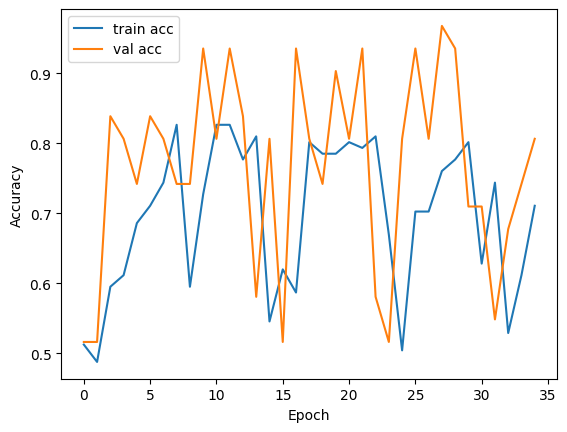

In [ ]:

loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")


plt.plot(history.history['accuracy'], label='train acc') # poner loss
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Al quitar las muestras, la LSTM simple ha empeorado 

### Validación cruzada sin videos ruidosos

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.8065 | Pérdida: 0.4171
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.6774 | Pérdida: 0.5932
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.8333 | Pérdida: 0.3759
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.6667 | Pérdida: 0.8070
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.7333 | Pérdida: 0.6256
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.7434**
| Desviación Estándar de la Precisión: **0.0669**


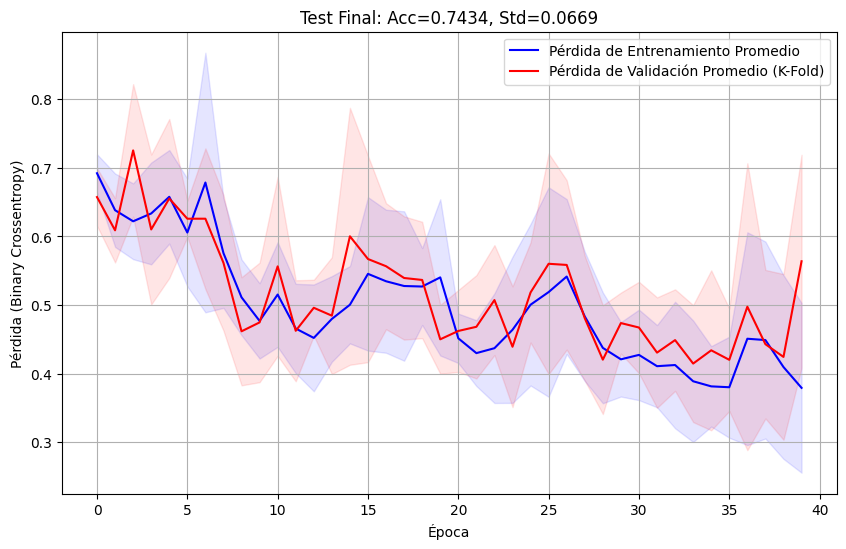

In [ ]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False)) 
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model


mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

Aqui obtenemos un mejor accuracy que el modelo con los videos ruidosos y obtenemos una desviación baja

### Validación cruzada ajustando parámetros sin videos ruidosos

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.7097 | Pérdida: 0.5603
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.9032 | Pérdida: 0.3773
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.7667 | Pérdida: 0.5512
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.8667 | Pérdida: 0.3520
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.7333 | Pérdida: 0.5527
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.7959**
| Desviación Estándar de la Precisión: **0.0758**


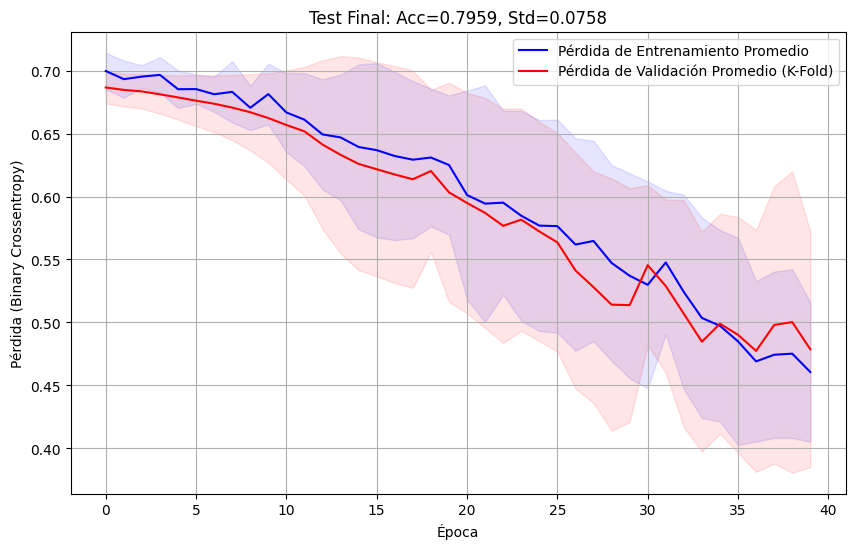

In [ ]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(32, return_sequences=False)) # <-- ¡Dropout recurrente añadido!
    
    # 3. Dropout (Regularización después de la LSTM)
    model.add(Dropout(0.2)) 
    model.add(Dense(32, activation='relu'))
    # 5. Dropout Opcional (Regularización después de la Densa)
    model.add(Dropout(0.2)) 
    model.add(Dense(1, activation='sigmoid'))
    
    custom_adam = Adam(learning_rate=0.0001) # <-- Nueva Tasa de Aprendizaje

    model.compile(
        loss='binary_crossentropy',
        optimizer=custom_adam,
        metrics=['accuracy']
    )
    return model

mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

Si mantenemos 32 unidades y aplicamos dropout y reducimos la tasa de aprendizaje obtenemos los mejores resultados hasta el momento, también se ve representado en la gráfica.  

(Los resultados han empeorado si dejamos la tasa de aprendizaje predefinida y mantenemos el dropout al 20% y bajamos a 32 unidades (en vez de usar 128))

## Ángulos articulares como datos de entrada del modelo

### Carga de datos

In [ ]:
# ## Coordenadas de ángulos articulares como datos de entrada del modelo
X_correct = np.load('../Data/Processed/Mixed_original_mirrored/mixed_correct_push_ups_angles.npy')
X_incorrect = np.load('../Data/Processed/Mixed_original_mirrored/mixed_wrong_push_ups_angles.npy')

# Creamos etiquetas
X = np.vstack((X_correct, X_incorrect))
y = np.array([1]*X_correct.shape[0] + [0]*X_incorrect.shape[0])  

In [23]:
# Dividimos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Definimos y entrenamos el modelo LSTM
timesteps = X_train.shape[1]  # 160 frames (numero de frames por secuencia)
features = X_train.shape[2]   # 66 valores por frame


### LSTM Simple

In [25]:
model = Sequential()
model.add(Masking(mask_value=0., input_shape=(timesteps, features)))  # ignorar padding
model.add(LSTM(64, return_sequences=False))  # 64 unidades LSTM, solo devolvemos la última salida
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))    # salida binaria

# Compilamos y entrenamos el modelo
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=16
)


Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5312 - loss: 0.6632 - val_accuracy: 0.6250 - val_loss: 0.6158
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7891 - loss: 0.5981 - val_accuracy: 0.7500 - val_loss: 0.6031
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8438 - loss: 0.5625 - val_accuracy: 0.9688 - val_loss: 0.5125
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6953 - loss: 0.5681 - val_accuracy: 0.8750 - val_loss: 0.5384
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8125 - loss: 0.5315 - val_accuracy: 0.8125 - val_loss: 0.5161
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8672 - loss: 0.4959 - val_accuracy: 0.9062 - val_loss: 0.4548
Epoch 7/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8516 - loss: 0.4659 - val_accuracy: 0.9375 - val_loss: 0.4304
Epoch 8/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8750 - loss: 0.4303 - val_accuracy: 0.9062 - val_loss: 0.4432


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8500 - loss: 0.3121 
Test Accuracy: 0.85


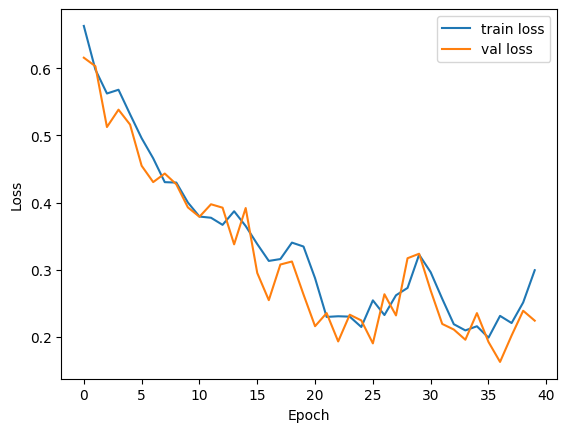

In [26]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")


plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Vemos que los resultados de la LSTM simple ya son considerablemente mejores, el accuracy esta entre el 80 y el 90 porciento 

### Validación cruzada 

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.8750 | Pérdida: 0.2301
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.9375 | Pérdida: 0.1721
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.9062 | Pérdida: 0.2150
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.8438 | Pérdida: 0.4057
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.9375 | Pérdida: 0.2268
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.9000**
| Desviación Estándar de la Precisión: **0.0364**


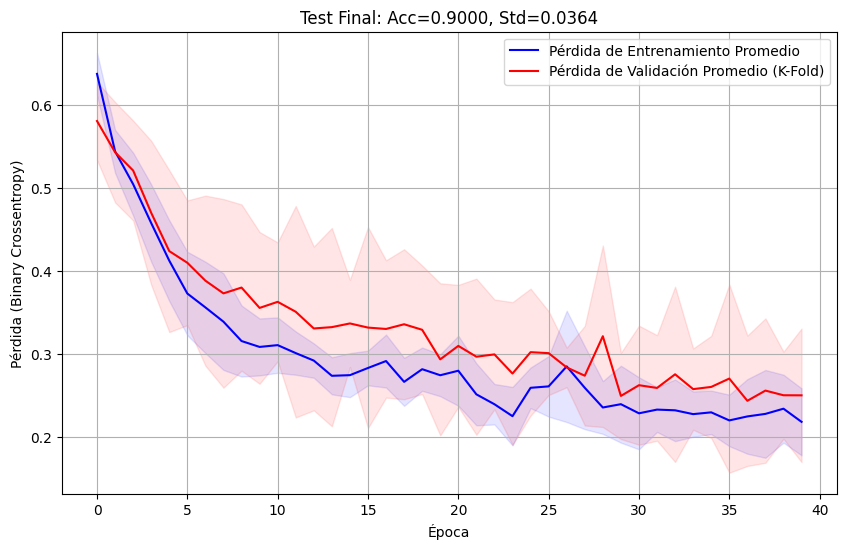

In [27]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False)) 
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model


mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

Los resultados son muy buenos, obtenemos una precision del 93.75%

### Validación cruzada ajustando parámetros 

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.8750 | Pérdida: 0.3348
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.8750 | Pérdida: 0.2739
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.9375 | Pérdida: 0.2855
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.8750 | Pérdida: 0.3941
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.9062 | Pérdida: 0.3075
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.8938**
| Desviación Estándar de la Precisión: **0.0250**


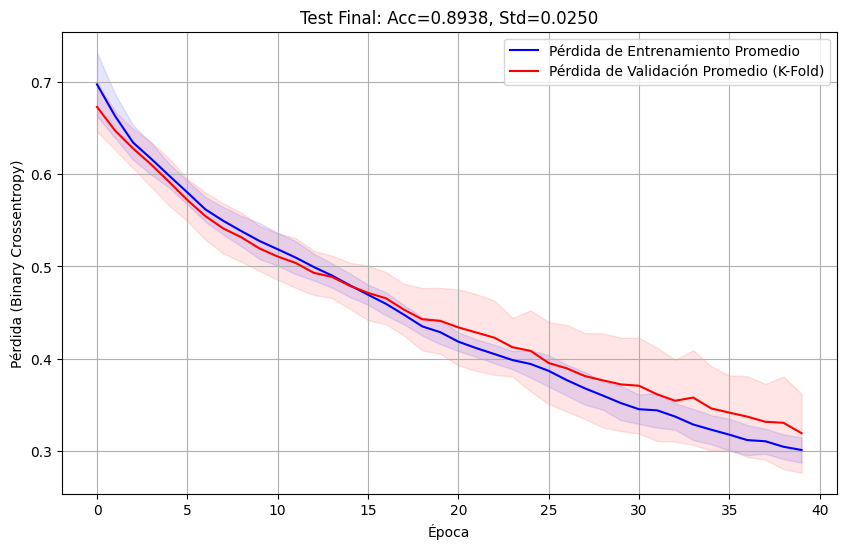

In [28]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False)) 
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    custom_adam = Adam(learning_rate=0.0001) # <-- Nueva Tasa de Aprendizaje

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer=custom_adam,
        metrics=['accuracy']
    )

    return model


mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

### LSTM Simple sin videos ruidosos 

In [29]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.losses import binary_crossentropy

# --- A. Entrenar un Modelo Único para el Análisis ---

# Re-entrenamos el modelo con todos los datos de entrenamiento (X_train)
# para obtener un buen conjunto de pesos para el análisis.
ANALYSIS_EPOCHS = 40  # Puedes usar 40 o el número de épocas que te dio el mejor resultado

print("Entrenando modelo para análisis de pérdida...")
analysis_model = create_lstm_model(timesteps, features)

# Entrenamos sin validación aquí, ya que el objetivo es el análisis de pérdida en X_train.
analysis_model.fit(
    X_train, y_train,
    epochs=ANALYSIS_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

# --- B. Calcular la Pérdida por Muestra en X_train ---

print("Calculando la pérdida individual por muestra...")
# 1. Obtener las predicciones del modelo en el conjunto de entrenamiento (X_train)
y_pred_proba = analysis_model.predict(X_train)

# Convertir y_train de la forma (80,) a la forma (80, 1) para que coincida con la predicción (80, 1).
y_train_reshaped = np.expand_dims(y_train, axis=-1)

# 2. Convertir a tensores para el cálculo de la pérdida
y_train_tf = tf.convert_to_tensor(y_train_reshaped, dtype=tf.float32) # <-- Usamos el array reformateado
y_pred_tf = tf.convert_to_tensor(y_pred_proba, dtype=tf.float32)

# 3. Calcular la Binary Crossentropy (pérdida) para cada muestra
# Esto ya no generará error ya que ambas variables son ahora 2D.
losses_per_sample = binary_crossentropy(y_train_tf, y_pred_tf)
losses_np = losses_per_sample.numpy()

# --- C. Identificar los Índices Ruidosos ---

# 1. Definir el porcentaje de ruido a buscar (ej: el 5% de las muestras con mayor pérdida)
PERCENTAJE_RUIDO = 0.05
num_total_samples = len(X_train)
num_noisy_samples = int(num_total_samples * PERCENTAJE_RUIDO)

# 2. Obtener los índices de las muestras ordenadas por pérdida (mayor a menor)
# np.argsort devuelve los índices que ordenarían el array
noisy_indices = np.argsort(losses_np)[::-1] # [::-1] invierte el orden para obtener los mayores primero

# 3. Seleccionar los top N índices más ruidosos
top_noisy_indices_X_train = noisy_indices[:num_noisy_samples]


# --- D. Resultados ---

print("\n" + "="*50)
print(f"ANÁLISIS DE RUIDO COMPLETADO ({num_total_samples} muestras en X_train)")
print(f"Se han identificado los {num_noisy_samples} índices ({PERCENTAJE_RUIDO*100}%) más ruidosos.")
print("="*50)

print("Top 5% de Muestras Ruidosas (Índice y Pérdida):")

# Imprimir los índices, su pérdida y la etiqueta real
for i in top_noisy_indices_X_train:
    print(f"Índice en X_train: {i} | Pérdida: {losses_np[i]:.4f} | Etiqueta Real: {y_train[i]}")

print("="*50)

Entrenando modelo para análisis de pérdida...
Calculando la pérdida individual por muestra...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

ANÁLISIS DE RUIDO COMPLETADO (160 muestras en X_train)
Se han identificado los 8 índices (5.0%) más ruidosos.
Top 5% de Muestras Ruidosas (Índice y Pérdida):
Índice en X_train: 62 | Pérdida: 1.2460 | Etiqueta Real: 0
Índice en X_train: 20 | Pérdida: 1.2212 | Etiqueta Real: 0
Índice en X_train: 13 | Pérdida: 1.2015 | Etiqueta Real: 0
Índice en X_train: 143 | Pérdida: 1.1510 | Etiqueta Real: 0
Índice en X_train: 1 | Pérdida: 1.0630 | Etiqueta Real: 0
Índice en X_train: 153 | Pérdida: 1.0328 | Etiqueta Real: 0
Índice en X_train: 83 | Pérdida: 0.9970 | Etiqueta Real: 0
Índice en X_train: 8 | Pérdida: 0.9769 | Etiqueta Real: 0


In [30]:
import numpy as np

# Índices identificados como ruidosos (de mayor a menor pérdida)
# NOTA: Debes usar los índices de tu array X_train actual
indices_a_eliminar = top_noisy_indices_X_train

print(f"Número de muestras antes de la eliminación: {len(X_train)}")

# 1. Eliminar las filas correspondientes de X_train
# axis=0 indica que se eliminan filas.
X_train_limpio = np.delete(X_train, indices_a_eliminar, axis=0)

# 2. Eliminar las etiquetas correspondientes de y_train
y_train_limpio = np.delete(y_train, indices_a_eliminar, axis=0)

print(f"Número de muestras después de la eliminación: {len(X_train_limpio)}")

# Asignar los arrays limpios de vuelta a las variables de entrenamiento
X_train = X_train_limpio
y_train = y_train_limpio

Número de muestras antes de la eliminación: 160
Número de muestras después de la eliminación: 152


In [31]:
model = Sequential()
model.add(Masking(mask_value=0., input_shape=(timesteps, features)))  # ignorar padding
model.add(LSTM(64, return_sequences=False))  # 64 unidades LSTM, solo devolvemos la última salida
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))    # salida binaria

# Compilamos y entrenamos el modelo
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=16
)


Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5207 - loss: 0.7600 - val_accuracy: 0.5161 - val_loss: 0.6764
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5372 - loss: 0.6712 - val_accuracy: 0.8387 - val_loss: 0.6218
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8017 - loss: 0.6085 - val_accuracy: 0.9032 - val_loss: 0.5792
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8512 - loss: 0.5758 - val_accuracy: 0.9355 - val_loss: 0.5458
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8430 - loss: 0.5484 - val_accuracy: 0.9677 - val_loss: 0.4929
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8017 - loss: 0.5478 - val_accuracy: 0.9032 - val_loss: 0.5114
Epoch 7/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8182 - loss: 0.5328 - val_accuracy: 0.9677 - val_loss: 0.4765
Epoch 8/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8595 - loss: 0.5003 - val_accuracy: 0.9355 - val_loss: 0.4456


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8500 - loss: 0.3218
Test Accuracy: 0.85


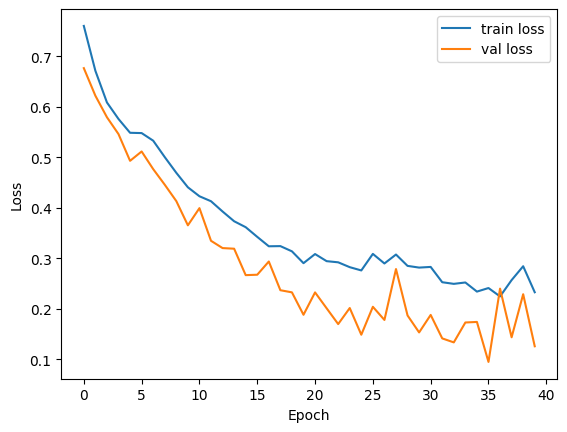

In [32]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")


plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

82% de accuracy

### Validación cruzada sin videos ruidosos

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.9032 | Pérdida: 0.2458
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.8710 | Pérdida: 0.1767
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.8667 | Pérdida: 0.2945
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.9000 | Pérdida: 0.2333
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.9667 | Pérdida: 0.1370
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.9015**
| Desviación Estándar de la Precisión: **0.0358**


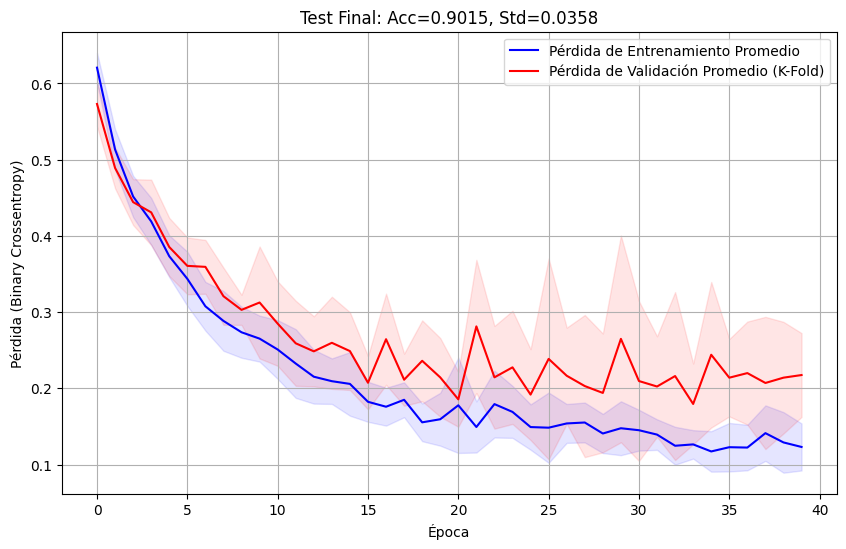

In [33]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False)) 
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model


mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

Este es el mejor modelo de todo el fichero en cuanto a valores de accuracy, desviación y valores de pérdida. Sobreajusta un poco aunque de manera controlada. 

### Validación cruzada ajustando parámetros sin videos ruidosos

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.9032 | Pérdida: 0.2785
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.9677 | Pérdida: 0.2856
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.8667 | Pérdida: 0.3935
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.9667 | Pérdida: 0.3657
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 1.0000 | Pérdida: 0.1914
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.9409**
| Desviación Estándar de la Precisión: **0.0486**


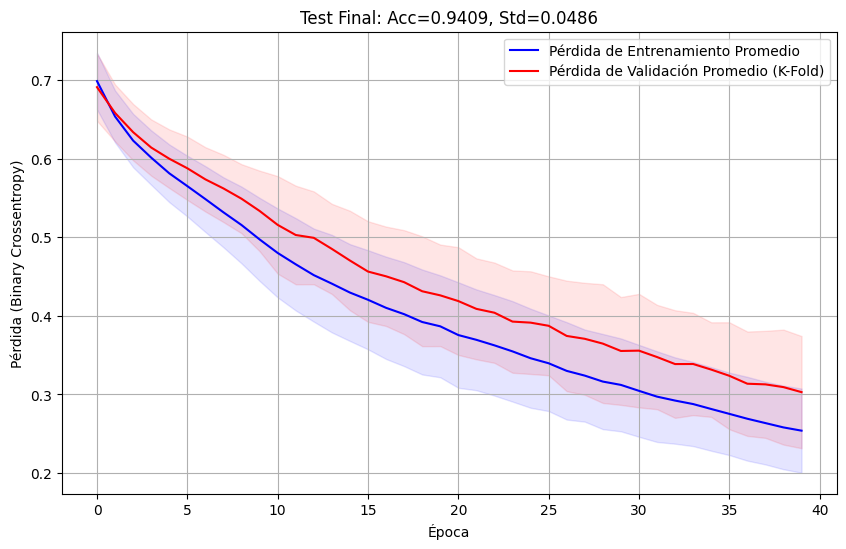

In [34]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False)) 
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    custom_adam = Adam(learning_rate=0.0001) # <-- Nueva Tasa de Aprendizaje

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer=custom_adam,
        metrics=['accuracy']
    )

    return model

mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

Vamos a probar a añadir dropout 

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.9677 | Pérdida: 0.1453
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.9032 | Pérdida: 0.2716
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.9000 | Pérdida: 0.3801
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.9333 | Pérdida: 0.1805
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 1.0000 | Pérdida: 0.0411
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.9409**
| Desviación Estándar de la Precisión: **0.0384**


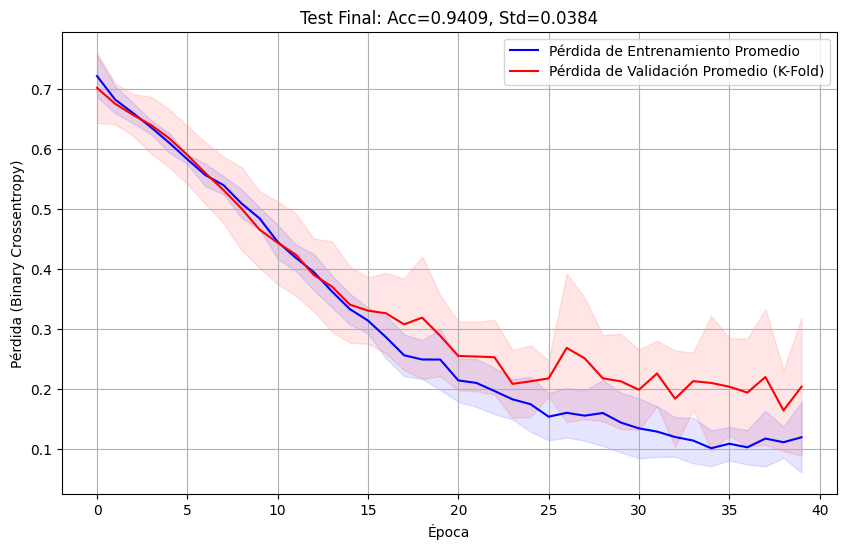

In [35]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=True)) 
    model.add(Dropout(0.2))
    model.add(LSTM(64, return_sequences=False)) 
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))

    custom_adam = Adam(learning_rate=0.0001) # <-- Nueva Tasa de Aprendizaje

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer=custom_adam,
        metrics=['accuracy']
    )

    return model

mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

Mejor hasta el moomento 